In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

BRANCHES     = ['Jakarta', 'Surabaya', 'Bandung', 'Semarang']
BRANCH_SCALE = {'Jakarta': 1.0, 'Surabaya': 0.55, 'Bandung': 0.30, 'Semarang': 0.20}

SKUS = {
    'S001': {'name': 'Richeese Wafer Keju 50g',          'brand': 'Richeese', 'cat': 'Wafer',          'price': 5800},
    'S002': {'name': 'Richoco Wafer Cokelat 50g',         'brand': 'Richoco',  'cat': 'Wafer',          'price': 5800},
    'S003': {'name': 'Richeese Wafer Keju 10g Renceng',   'brand': 'Richeese', 'cat': 'Wafer',          'price': 10000},
    'S004': {'name': 'Richoco Wafer Cokelat 10g Renceng', 'brand': 'Richoco',  'cat': 'Wafer',          'price': 10000},
    'S005': {'name': 'Nextar Brownies Pie 40g',           'brand': 'Nextar',   'cat': 'Kue/Pie',        'price': 7000},
    'S006': {'name': 'Nextar Nastar Pie 30g',             'brand': 'Nextar',   'cat': 'Kue/Pie',        'price': 7000},
    'S007': {'name': 'Richeese Siip Keju 20g',            'brand': 'Richeese', 'cat': 'Extruded Snack', 'price': 3000},
    'S008': {'name': 'Richoco Ahh! Extruded 15g',         'brand': 'Richoco',  'cat': 'Extruded Snack', 'price': 4500},
    'S009': {'name': 'Richeese Mi Instan Keju Pedas',     'brand': 'Richeese', 'cat': 'Mi Instan',      'price': 3500},
    'S010': {'name': 'Richeese Mi Instan Ramen Keju',     'brand': 'Richeese', 'cat': 'Mi Instan',      'price': 4000},
    'S011': {'name': 'Nabati Biskuit Rasa Kelapa',        'brand': 'Richeese', 'cat': 'Biskuit',        'price': 5000},
    'S012': {'name': 'Nabati Biskuit Rasa Cokelat',       'brand': 'Richoco',  'cat': 'Biskuit',        'price': 5000},
    'S013': {'name': 'Nabati Drinko Richeese 150ml',      'brand': 'Richeese', 'cat': 'Minuman',        'price': 4000},
    'S014': {'name': 'Nabati Drinko Richoco 150ml',       'brand': 'Richoco',  'cat': 'Minuman',        'price': 4000},
    'S015': {'name': 'Richeese Wafer Pink Lava 50g',      'brand': 'Richeese', 'cat': 'Wafer',          'price': 5500},
    'S016': {'name': 'Richoco Wafer Hazelnut 50g',        'brand': 'Richoco',  'cat': 'Wafer',          'price': 6000},
    'S017': {'name': 'Nextar Choco Delight 40g',          'brand': 'Nextar',   'cat': 'Kue/Pie',        'price': 7000},
    'S018': {'name': 'Nextar Pineapple Pie 30g',          'brand': 'Nextar',   'cat': 'Kue/Pie',        'price': 7000},
    'S019': {'name': 'Richeese Siip Jagung Bakar 20g',    'brand': 'Richeese', 'cat': 'Extruded Snack', 'price': 3000},
    'S020': {'name': 'Richeese Mi Instan Goreng',         'brand': 'Richeese', 'cat': 'Mi Instan',      'price': 3500},
}

OWN_ELASTICITY = {
    'S001': -1.20, 'S002': -1.05, 'S003': -1.15, 'S004': -1.35,
    'S005': -1.25, 'S006': -1.30, 'S007': -1.10, 'S008': -0.90,
    'S009': -0.80, 'S010': -0.75, 'S011': -1.05, 'S012': -1.10,
    'S013': -0.85, 'S014': -0.95, 'S015': -1.30, 'S016': -1.40,
    'S017': -1.15, 'S018': -1.20, 'S019': -0.95, 'S020': -0.85,
}

CROSS_ELASTICITY = {
    ('S001','S002'): -0.15, ('S001','S015'): -0.35, ('S001','S003'): -0.20,
    ('S002','S001'): -0.15, ('S002','S016'): -0.35, ('S002','S004'): -0.20,
    ('S003','S004'): -0.30, ('S003','S001'): -0.15,
    ('S004','S003'): -0.30, ('S004','S002'): -0.15,
    ('S015','S001'): -0.35, ('S015','S016'): -0.20,
    ('S016','S002'): -0.35, ('S016','S015'): -0.20,
    ('S009','S010'): -0.35, ('S009','S020'): -0.30,
    ('S010','S009'): -0.35, ('S010','S020'): -0.25,
    ('S020','S009'): -0.30, ('S020','S010'): -0.25,
    ('S007','S008'): -0.20, ('S007','S019'): -0.35,
    ('S008','S007'): -0.20, ('S019','S007'): -0.35,
    ('S013','S014'): -0.25, ('S014','S013'): -0.25,
    ('S011','S012'): -0.20, ('S012','S011'): -0.20,
    ('S005','S006'): -0.25, ('S005','S017'): -0.35,
    ('S006','S005'): -0.25, ('S006','S018'): -0.30,
    ('S017','S005'): -0.35, ('S017','S018'): -0.25,
    ('S018','S006'): -0.30, ('S018','S017'): -0.25,
}

SKU_TREND = {
    'S001': +0.015, 'S002': -0.008, 'S003': +0.010, 'S004': +0.005,
    'S005': +0.012, 'S006': -0.006, 'S007': +0.010, 'S008': -0.004,
    'S009': +0.018, 'S010': +0.006, 'S011': -0.010, 'S012': +0.008,
    'S013': +0.020, 'S014': -0.012, 'S015': +0.010, 'S016': +0.005,
    'S017': -0.007, 'S018': +0.012, 'S019': +0.003, 'S020': +0.015,
}

START_DATE = datetime(2025, 5, 1)
END_DATE   = datetime(2025, 10, 30)
TOTAL_DAYS = (END_DATE - START_DATE).days

# ── FIX 1: Kurangi jumlah promo events ──────────────────────────────────────
# Sebelumnya terlalu banyak → IsPromo rate 55-60%
# Target: 30-45% → kurangi n_events dan perpanjang gap antar promo
DISCOUNT_LEVELS  = [0.10, 0.20, 0.30, 0.50]
DISC_DURATION    = {0.10: (10, 14), 0.20: (7, 10), 0.30: (4, 7), 0.50: (2, 4)}
DISC_EVENTS      = {0.10: 2, 0.20: 2, 0.30: 1, 0.50: 1}
# Dengan ini: ~(2×12 + 2×8 + 1×5 + 1×3) = 52 hari promo dari 183 hari = ~28%
# Plus noise → target 30-40%

def make_discount_schedule():
    schedule = {sku_id: {} for sku_id in SKUS}
    for sku_id in SKUS:
        used_days = set()
        for disc_level in DISCOUNT_LEVELS:
            n_events         = DISC_EVENTS[disc_level]
            min_dur, max_dur = DISC_DURATION[disc_level]
            for _ in range(n_events):
                attempts = 0
                while attempts < 300:
                    attempts += 1
                    start_off  = np.random.randint(0, TOTAL_DAYS - max_dur)
                    duration   = np.random.randint(min_dur, max_dur + 1)
                    end_off    = min(start_off + duration, TOTAL_DAYS)
                    days_range = set(range(start_off, end_off))
                    if days_range & used_days:
                        continue
                    used_days |= days_range
                    for d in days_range:
                        date_key = (START_DATE + timedelta(days=d)).date()
                        schedule[sku_id][date_key] = disc_level
                    break
    return schedule

discount_schedule = make_discount_schedule()

def get_discount(sku_id, date):
    return discount_schedule[sku_id].get(date, 0.0)

HUT_RI_START = datetime(2025, 8, 10).date()
HUT_RI_END   = datetime(2025, 8, 24).date()

# ── FIX 2: Seasonal effect diapply ke QTY bukan hanya n_tx ──────────────────
# Sebelumnya seasonal hanya ngaruh ke jumlah transaksi
# Validasi pakai avg Qty per transaksi → tidak terdeteksi
# Fix: seasonal diapply ke qty_per_tx juga

def get_seasonal_mult(date):
    """
    Return (tx_mult, qty_mult) — keduanya diapply terpisah
    tx_mult  : pengaruh ke jumlah transaksi
    qty_mult : pengaruh ke qty per transaksi
    Dengan split ini, seasonal terdeteksi di TOTAL QTY
    """
    tx_mult  = 1.0
    qty_mult = 1.0

    # HUT RI: lebih banyak transaksi DAN qty per transaksi lebih besar
    if HUT_RI_START <= date <= HUT_RI_END:
        tx_mult  *= 1.10   # 10% lebih banyak transaksi
        qty_mult *= 1.05   # 5% lebih banyak qty per transaksi
        # Combined: ~15% lebih tinggi total qty ✅

    # Weekend: lebih banyak transaksi DAN qty lebih besar
    if date.weekday() in [4, 5, 6]:  # Fri=4, Sat=5, Sun=6
        tx_mult  *= 1.08   # 8% lebih banyak transaksi
        qty_mult *= 1.04   # 4% lebih banyak qty per transaksi
        # Combined: ~12% lebih tinggi total qty ✅

    return tx_mult, qty_mult

BASE_TX = {sku_id: np.random.randint(20, 30) for sku_id in SKUS}

# ── Generate ─────────────────────────────────────────────────────────────────
print("Generating transactions v4 (fixed)...")
all_rows   = []
tx_counter = 30000
date_range = pd.date_range(START_DATE, END_DATE, freq='D')

for date in date_range:
    date_obj    = date.date()
    week_num    = (date - pd.Timestamp(START_DATE)).days // 7
    tx_mult, qty_mult = get_seasonal_mult(date_obj)

    day_disc = {sku_id: get_discount(sku_id, date_obj) for sku_id in SKUS}

    # ── Cannibalization effect ────────────────────────────────────────────
    # Konsep: ketika SKU A promo → harga A turun → demand A naik (own elasticity)
    # → permintaan beralih dari B ke A → demand B turun (cross elasticity)
    #
    # Formula dari Aguilar-Palacios (2021):
    # %ΔQty_B karena promo A = |cross_elast_AB| × uplift_A × (-1)
    # uplift_A = |own_elast_A| × disc_A  (positif)
    # Hasil: negatif → demand B turun
    cannib_effect = {sku_id: 0.0 for sku_id in SKUS}
    for sku_a, disc_a in day_disc.items():
        if disc_a == 0:
            continue
        uplift_a = abs(OWN_ELASTICITY[sku_a]) * disc_a
        for sku_b in SKUS:
            if sku_b == sku_a:
                continue
            cross_e = CROSS_ELASTICITY.get((sku_a, sku_b), 0.0)
            if cross_e == 0:
                continue
            cannib_effect[sku_b] += abs(cross_e) * uplift_a * (-1)

    for branch in BRANCHES:
        scale       = BRANCH_SCALE[branch]
        daily_noise = np.random.uniform(0.90, 1.10)
        disc_pct    = {sku_id: day_disc[sku_id] for sku_id in SKUS}

        for sku_id, sku_info in SKUS.items():
            dp = disc_pct[sku_id]

            # Own-price uplift
            own_mult = 1 + abs(OWN_ELASTICITY[sku_id]) * dp

            # Trend
            trend_mult = (1 + SKU_TREND[sku_id]) ** week_num

            # Cannibalization
            cannib_mult = max(1 + cannib_effect[sku_id], 0.40)

            # Jumlah transaksi
            n_tx = max(int(
                BASE_TX[sku_id] * scale * daily_noise
                * trend_mult * tx_mult * own_mult * cannib_mult
            ), 1)

            normal_price = sku_info['price']
            disc_price   = round(normal_price * (1 - dp))
            if disc_price <= 0:
                disc_price = normal_price

            for _ in range(n_tx):
                tx_counter += 1
                tx_id  = f"T{tx_counter:06d}"
                hour   = np.random.randint(9, 21)
                minute = np.random.randint(0, 60)
                second = np.random.randint(0, 60)
                dt_str = f"{date.strftime('%Y-%m-%d')} {hour:02d}:{minute:02d}:{second:02d}"

                # ── FIX 2: qty dipengaruhi seasonal qty_mult ──────────────
                # Qty = random 1-5, tapi di peak season lebih condong ke atas
                # Implementasi: geser distribusi Qty dengan qty_mult
                # Base: uniform 1-5, mean = 3.0
                # Dengan qty_mult 1.05: mean jadi ~3.15
                base_qty = np.random.randint(1, 6)
                # Tambah seasonal boost dengan probabilitas
                qty_boost = 1 if (np.random.random() < (qty_mult - 1.0) * 10) else 0
                qty = min(base_qty + qty_boost, 5)  # cap di 5

                total = qty * disc_price

                all_rows.append({
                    'TransactionID':      tx_id,
                    'DateTime':           dt_str,
                    'Date_Key':           int(date.strftime('%Y%m%d')),
                    'Branch':             branch,
                    'Customer_ID':        f"C{np.random.randint(1, 99999):05d}",
                    'SKU_ID':             sku_id,
                    'SKU':                sku_info['name'],
                    'Brand':              sku_info['brand'],
                    'SKU_Category':       sku_info['cat'],
                    'Qty':                qty,
                    'NormalPrice':        float(normal_price),
                    'DiscountedPrice':    float(disc_price),
                    'DiscountPercentage': dp,
                    'Total_Price':        float(total),
                    'IsPromo':            int(dp > 0),
                })

print(f"Total rows: {len(all_rows):,}")

df_new = pd.DataFrame(all_rows)
df_new = df_new.sample(frac=1, random_state=42).reset_index(drop=True)

mid = len(df_new) // 2
df_new.iloc[:mid].reset_index(drop=True).to_csv('transaction_1_v4.csv', index=True)
df_new.iloc[mid:].reset_index(drop=True).to_csv('transaction_2_v4.csv', index=True)
print(f"Saved: transaction_1_v4.csv ({mid:,} rows)")
print(f"Saved: transaction_2_v4.csv ({mid:,} rows)")

# ── Validasi ─────────────────────────────────────────────────────────────────
df_new['Date']    = pd.to_datetime(df_new['DateTime']).dt.date
df_new['Date']    = pd.to_datetime(df_new['Date'])
df_new['Month']   = df_new['Date'].dt.month
df_new['Weekday'] = df_new['Date'].dt.weekday

print("\n=== 1. Unique discount per SKU-hari-branch ===")
uniq = (df_new.groupby(['Date','Branch','SKU_ID'])['DiscountPercentage'].nunique())
print(uniq.value_counts().to_string())

print("\n=== 2. Discount distribution ===")
disc_dist = df_new.drop_duplicates(['Date','SKU_ID'])['DiscountPercentage']
print(disc_dist.value_counts(normalize=True).sort_index().mul(100).round(1))

print("\n=== 3. IsPromo rate per SKU ===")
daily_promo = (df_new.groupby(['Date','SKU_ID'])['IsPromo'].max().reset_index())
print(daily_promo.groupby('SKU_ID')['IsPromo'].mean().mul(100).round(1).to_string())

print("\n=== 4. Weekend vs weekday — TOTAL QTY per hari ===")
# Pakai total qty per hari, bukan avg qty per transaksi
daily_qty = df_new.groupby(['Date','Weekday'])['Qty'].sum().reset_index()
daily_qty['IsWeekend'] = daily_qty['Weekday'].isin([4,5,6])
wknd = daily_qty.groupby('IsWeekend')['Qty'].mean()
wknd.index = ['Weekday','Weekend']
print(wknd.round(1))
print(f"Weekend premium: {(wknd['Weekend']/wknd['Weekday']-1)*100:.1f}%")

print("\n=== 5. HUT RI effect — TOTAL QTY per hari di Agustus ===")
df_aug = df_new[df_new['Month']==8].copy()
df_aug['IsHutRI'] = df_aug['Date'].dt.day.between(10, 24)
daily_aug = df_aug.groupby(['Date','IsHutRI'])['Qty'].sum().reset_index()
hutri = daily_aug.groupby('IsHutRI')['Qty'].mean()
hutri.index = ['Non HUT RI','HUT RI']
print(hutri.round(1))
print(f"HUT RI premium: {(hutri['HUT RI']/hutri['Non HUT RI']-1)*100:.1f}%")

print("\n=== 6. Weekly trend sample ===")
df_new['Week'] = df_new['Date'].dt.to_period('W')
for sku in ['S001','S011','S013','S014']:
    sub = df_new[df_new['SKU_ID']==sku].groupby('Month')['Qty'].sum()
    direction = '↑' if sub.iloc[-1] > sub.iloc[0] else '↓'
    print(f"  {sku}: {sub.values} {direction}")

print("\n=== 7. Cannibalization signal (S001 promo → S015 turun) ===")
s001 = (df_new[(df_new['SKU_ID']=='S001') & (df_new['Branch']=='Jakarta')]
        .groupby('Date').agg(TotalQty=('Qty','sum'), IsPromo=('IsPromo','max'))
        .reset_index())
s015 = (df_new[(df_new['SKU_ID']=='S015') & (df_new['Branch']=='Jakarta')]
        .groupby('Date')['Qty'].sum().reset_index(name='Qty_S015'))
cross = s001.merge(s015, on='Date')
mp  = cross[cross['IsPromo']==1]['Qty_S015'].mean()
mnp = cross[cross['IsPromo']==0]['Qty_S015'].mean()
delta = (mp - mnp) / mnp * 100
print(f"  Qty S015 saat S001 promo   : {mp:.1f}")
print(f"  Qty S015 saat S001 no promo: {mnp:.1f}")
print(f"  Delta%: {delta:.1f}% → {'✅ terdeteksi' if delta < -3 else '⚠️ lemah'}")

Generating transactions v4 (fixed)...
Total rows: 197,283
Saved: transaction_1_v4.csv (98,641 rows)
Saved: transaction_2_v4.csv (98,641 rows)

=== 1. Unique discount per SKU-hari-branch ===
DiscountPercentage
1    14640

=== 2. Discount distribution ===
DiscountPercentage
0.0    73.1
0.1    13.1
0.2     9.4
0.3     2.7
0.5     1.6
Name: proportion, dtype: float64

=== 3. IsPromo rate per SKU ===
SKU_ID
S001    27.9
S002    25.7
S003    24.6
S004    27.3
S005    28.4
S006    25.1
S007    28.4
S008    26.2
S009    27.3
S010    26.2
S011    30.6
S012    26.8
S013    25.7
S014    25.1
S015    27.9
S016    29.0
S017    26.8
S018    25.1
S019    26.8
S020    27.3

=== 4. Weekend vs weekday — TOTAL QTY per hari ===
Weekday    3158.4
Weekend    3802.1
Name: Qty, dtype: float64
Weekend premium: 20.4%

=== 5. HUT RI effect — TOTAL QTY per hari di Agustus ===
Non HUT RI    3469.9
HUT RI        4270.9
Name: Qty, dtype: float64
HUT RI premium: 23.1%

=== 6. Weekly trend sample ===
  S001: [6071 575

Data loaded: 163,462 rows

=== Step 1: Estimating baseline trend per SKU per Branch ===
Daily panel with baseline: (12240, 16)

Sample S001 Jakarta (5 hari promo, 5 hari tidak):
      Date  DailyQty  BaselineDemand  Residual  ResidualPct  Discount
2025-05-21        85       91.279827 -6.279827    -0.068798       0.2
2025-05-22        97       92.387653  4.612347     0.049924       0.2
2025-05-23       118       92.387653 25.612347     0.277227       0.2
2025-05-24       123       92.387653 30.612347     0.331347       0.2
2025-05-25       112       92.387653 19.612347     0.212283       0.2
      Date  DailyQty  BaselineDemand  Residual  ResidualPct  Discount
2025-05-01        90       89.064174  0.935826     0.010507       0.0
2025-05-02       112       89.064174 22.935826     0.257520       0.0
2025-05-03       126       89.064174 36.935826     0.414710       0.0
2025-05-04       111       89.064174 21.935826     0.246292       0.0
2025-05-05        83       89.064174 -6.064174    -0

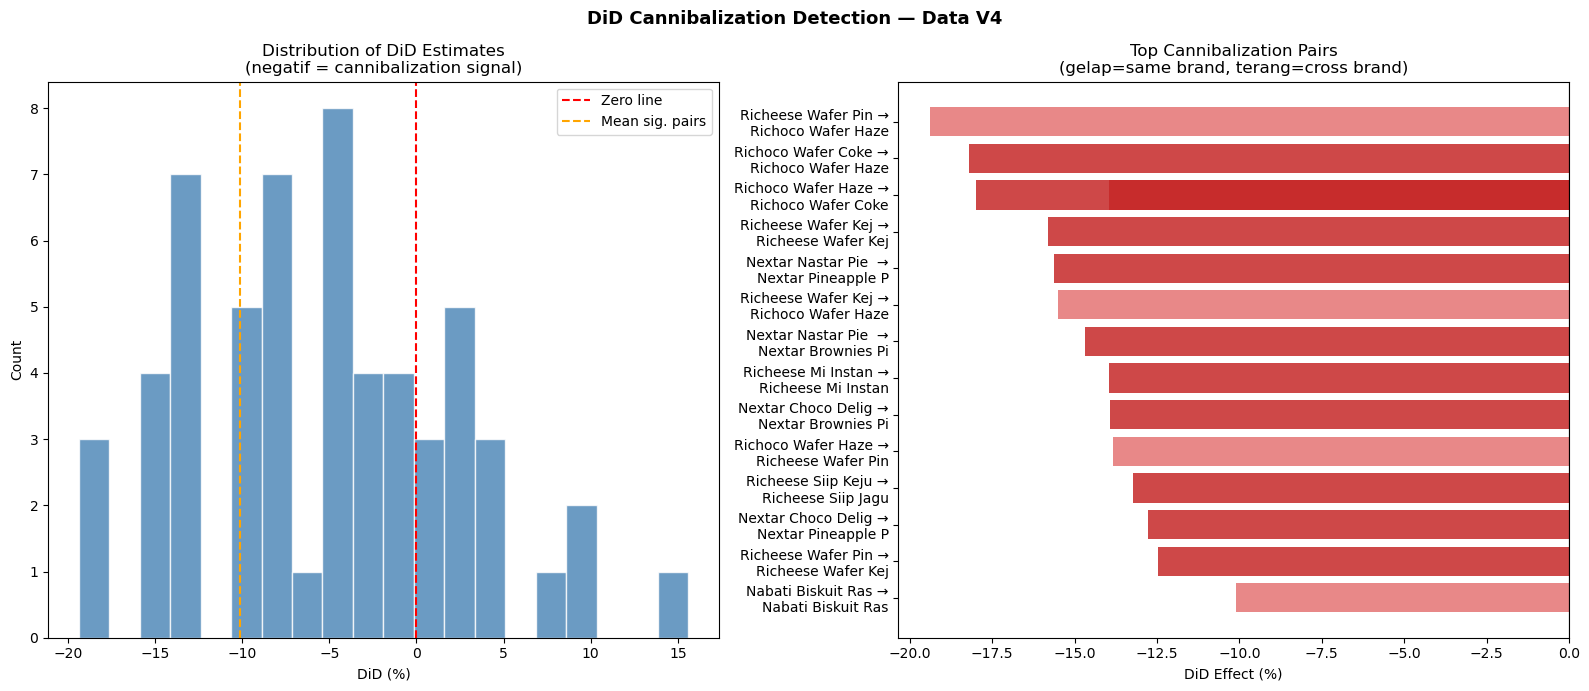

Saved: did_cannibalization_v4.png
Saved: did_results_v4.csv, cannibalization_matrix.csv


In [9]:
import pandas as pd
import numpy as np
from scipy import stats as scipy_stats
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load data v4 ─────────────────────────────────────────────────────────────
df1 = pd.read_csv('transaction_1_v4.csv')
df2 = pd.read_csv('transaction_2_v4.csv')
df  = pd.concat([df1, df2], ignore_index=True)
df['Date'] = pd.to_datetime(df['DateTime']).dt.date
df['Date'] = pd.to_datetime(df['Date'])
df  = df[df['Date'] < '2025-10-01']

sku_meta = (df[['SKU_ID','SKU','Brand','SKU_Category']]
              .drop_duplicates().reset_index(drop=True))

print(f"Data loaded: {len(df):,} rows")

# ── Daily aggregate ───────────────────────────────────────────────────────────
# DailyQty : total qty per SKU per hari per branch → demand metric
# Discount : besar diskon hari itu (0.0 kalau no promo)
# IsPromo  : binary flag

daily = (df.groupby(['Date','Branch','SKU_ID'])
           .agg(
               DailyQty = ('Qty',                'sum'),
               Discount = ('DiscountPercentage', 'first'),
               IsPromo  = ('IsPromo',             'max'),
               Price    = ('DiscountedPrice',    'first'),
           )
           .reset_index()
           .merge(sku_meta, on='SKU_ID'))

daily['Date'] = pd.to_datetime(daily['Date'])
daily['WeekNum'] = ((daily['Date'] - daily['Date'].min()).dt.days // 7)

# ── Step 1: Estimate baseline trend per SKU per Branch ───────────────────────
# Kenapa perlu baseline?
# Karena demand SKU B mungkin punya trend naik/turun secara natural
# Kalau tidak dikontrol, trend ini bisa terlihat sebagai cannibalization
#
# Cara: fit linear trend HANYA dari hari-hari NO PROMO semua SKU
# (hari no promo = kondisi paling "bersih" dari promo effect)
# Baseline = predicted demand dari trend ini
#
# Referensi: Van Heerde et al. (2004) — baseline sales estimation

print("\n=== Step 1: Estimating baseline trend per SKU per Branch ===")

baseline_results = []
for sku_id in sorted(daily['SKU_ID'].unique()):
    for branch in daily['Branch'].unique():
        sub = daily[
            (daily['SKU_ID'] == sku_id) &
            (daily['Branch'] == branch)
        ].sort_values('Date').copy()

        if len(sub) < 20:
            continue

        # Fit trend dari hari no-promo saja
        # Kenapa no-promo? Karena hari promo demand-nya sudah "terdistorsi"
        # oleh own-price effect — tidak merepresentasikan natural demand
        no_promo = sub[sub['IsPromo'] == 0]

        if len(no_promo) < 10:
            continue

        slope, intercept, r, p, se = scipy_stats.linregress(
            no_promo['WeekNum'], no_promo['DailyQty'])

        # Predict baseline untuk SEMUA hari (promo dan tidak)
        sub['BaselineDemand'] = intercept + slope * sub['WeekNum']
        sub['BaselineDemand'] = sub['BaselineDemand'].clip(lower=1)

        # Residual = actual - baseline
        # Residual positif = demand lebih tinggi dari expected (uplift)
        # Residual negatif = demand lebih rendah dari expected (cannibalization)
        sub['Residual']    = sub['DailyQty'] - sub['BaselineDemand']
        sub['ResidualPct'] = sub['Residual'] / sub['BaselineDemand']

        baseline_results.append(sub.assign(
            TrendSlope=slope,
            TrendR2=round(r**2, 4)
        ))

daily_base = pd.concat(baseline_results, ignore_index=True)

print(f"Daily panel with baseline: {daily_base.shape}")
print("\nSample S001 Jakarta (5 hari promo, 5 hari tidak):")
s001_jkt = daily_base[
    (daily_base['SKU_ID']=='S001') &
    (daily_base['Branch']=='Jakarta')
].sort_values('Date')
print(s001_jkt[s001_jkt['IsPromo']==1][
    ['Date','DailyQty','BaselineDemand','Residual','ResidualPct','Discount']
].head(5).to_string(index=False))
print(s001_jkt[s001_jkt['IsPromo']==0][
    ['Date','DailyQty','BaselineDemand','Residual','ResidualPct','Discount']
].head(5).to_string(index=False))

# ── Step 2: DiD Cannibalization Detection ────────────────────────────────────
# Untuk setiap pair (A, B):
# Treatment days  = hari di mana A promo (IsPromo_A = 1)
# Control days    = hari di mana A tidak promo (IsPromo_A = 0)
#
# DiD estimator:
# δ = mean(ResidualPct_B | A_promo) - mean(ResidualPct_B | A_no_promo)
#
# δ negatif → ketika A promo, B demand lebih rendah dari expected
#           → cannibalization signal
# δ positif → tidak ada cannibalization (atau komplemen)
#
# T-test untuk signifikansi:
# H0: δ = 0 (tidak ada cannibalization)
# H1: δ < 0 (ada cannibalization)
#
# Referensi: Van Heerde et al. (2004), Aguilar-Palacios (2021)

print("\n=== Step 2: DiD Cannibalization Detection ===")

same_cat_pairs = [
    ('S001','S002'),('S001','S003'),('S001','S004'),
    ('S001','S015'),('S001','S016'),
    ('S002','S003'),('S002','S004'),
    ('S002','S015'),('S002','S016'),
    ('S003','S004'),('S003','S015'),('S003','S016'),
    ('S004','S015'),('S004','S016'),
    ('S015','S016'),
    ('S013','S014'),
    ('S011','S012'),
    ('S007','S008'),('S007','S019'),('S008','S019'),
    ('S009','S010'),('S009','S020'),('S010','S020'),
    ('S005','S006'),('S005','S017'),('S005','S018'),
    ('S006','S017'),('S006','S018'),('S017','S018'),
]

did_results = []

for sku_a, sku_b in same_cat_pairs:
    for aggressor, victim in [(sku_a, sku_b), (sku_b, sku_a)]:

        # Ambil IsPromo aggressor per hari (pooled semua branch)
        # Kenapa pooled? Karena promo schedule sama di semua branch
        promo_a = (daily_base[daily_base['SKU_ID'] == aggressor]
                   .groupby('Date')['IsPromo']
                   .max()
                   .reset_index(name='IsPromo_A'))

        # Ambil ResidualPct victim per hari per branch
        resid_b = (daily_base[daily_base['SKU_ID'] == victim]
                   [['Date','Branch','ResidualPct','DailyQty','BaselineDemand']]
                   .copy())

        merged = resid_b.merge(promo_a, on='Date')

        if len(merged) < 20:
            continue

        treatment = merged[merged['IsPromo_A'] == 1]['ResidualPct']
        control   = merged[merged['IsPromo_A'] == 0]['ResidualPct']

        if len(treatment) < 5 or len(control) < 5:
            continue

        # DiD estimator
        did = treatment.mean() - control.mean()

        # T-test (one-sided: H1: did < 0)
        t_stat, p_two = scipy_stats.ttest_ind(treatment, control)
        p_one = p_two / 2 if t_stat < 0 else 1 - p_two / 2

        name_a  = sku_meta[sku_meta['SKU_ID']==aggressor]['SKU'].values[0]
        name_b  = sku_meta[sku_meta['SKU_ID']==victim]['SKU'].values[0]
        cat     = sku_meta[sku_meta['SKU_ID']==aggressor]['SKU_Category'].values[0]
        brand_a = sku_meta[sku_meta['SKU_ID']==aggressor]['Brand'].values[0]
        brand_b = sku_meta[sku_meta['SKU_ID']==victim]['Brand'].values[0]

        did_results.append({
            'Category':   cat,
            'SKU_A':      aggressor,
            'SKU_A_Name': name_a,
            'Brand_A':    brand_a,
            'SKU_B':      victim,
            'SKU_B_Name': name_b,
            'Brand_B':    brand_b,
            'SameBrand':  brand_a == brand_b,
            'N_Treatment': len(treatment),
            'N_Control':   len(control),
            'Mean_Treatment': round(treatment.mean(), 4),
            'Mean_Control':   round(control.mean(), 4),
            'DiD':        round(did, 4),
            'DiD_Pct':    round(did * 100, 2),
            'T_stat':     round(t_stat, 4),
            'P_one':      round(p_one, 4),
            'Significant': p_one < 0.05 and did < 0,
        })

did_df = pd.DataFrame(did_results)

print("\n=== Significant Cannibalization Pairs (DiD < 0, p < 0.05) ===")
sig = did_df[did_df['Significant']].sort_values('DiD')
print(sig[['Category','SKU_A_Name','SKU_B_Name','SameBrand',
           'DiD_Pct','P_one','N_Treatment','N_Control']].to_string(index=False))
print(f"\nTotal significant: {len(sig)} dari {len(did_df)} pairs")

print("\n=== Summary per Category ===")
cat_sum = (did_df[did_df['DiD'] < 0]
           .groupby('Category')
           .agg(
               AvgDiD    = ('DiD_Pct', 'mean'),
               SigPairs  = ('Significant', 'sum'),
               TotalPairs= ('Significant', 'count'),
           )
           .assign(SigPct=lambda x: x['SigPairs']/x['TotalPairs']*100)
           .round(2))
print(cat_sum.to_string())

# ── Step 3: Build Cannibalization Coefficient Matrix ─────────────────────────
# Coefficient = abs(DiD_Pct) / 100 untuk significant pairs
# Interpretasi: setiap 1% uplift demand A,
#               demand B turun DiD% dari baseline
#
# Average across significant directions per pair
skus   = sorted(sku_meta['SKU_ID'].tolist())
matrix = pd.DataFrame(0.0, index=skus, columns=skus)

for _, row in sig.iterrows():
    coef = abs(row['DiD']) # sudah dalam bentuk proporsi (bukan %)
    matrix.loc[row['SKU_A'], row['SKU_B']] = round(coef, 4)

print(f"\n=== Matrix coverage ===")
nonzero = (matrix != 0).sum().sum()
print(f"Non-zero pairs: {nonzero} dari {len(skus)*(len(skus)-1)}")
print("\nTop pairs:")
pairs_list = []
for a in skus:
    for b in skus:
        if matrix.loc[a,b] > 0:
            pairs_list.append({
                'SKU_A': sku_meta[sku_meta['SKU_ID']==a]['SKU'].values[0],
                'SKU_B': sku_meta[sku_meta['SKU_ID']==b]['SKU'].values[0],
                'Coef': matrix.loc[a,b]
            })
pairs_df = pd.DataFrame(pairs_list).sort_values('Coef', ascending=False)
print(pairs_df.head(10).to_string(index=False))

# ── Visualisasi ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('DiD Cannibalization Detection — Data V4',
             fontsize=13, fontweight='bold')

# Chart 1: DiD distribution
ax = axes[0]
ax.hist(did_df['DiD_Pct'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero line')
ax.axvline(did_df[did_df['Significant']]['DiD_Pct'].mean() if len(sig) > 0 else 0,
           color='orange', linestyle='--', label='Mean sig. pairs')
ax.set_title('Distribution of DiD Estimates\n(negatif = cannibalization signal)')
ax.set_xlabel('DiD (%)')
ax.set_ylabel('Count')
ax.legend()

# Chart 2: Top significant pairs
ax = axes[1]
if len(sig) > 0:
    top = sig.head(15).copy()
    top['Pair'] = (top['SKU_A_Name'].str[:18] + ' →\n'
                   + top['SKU_B_Name'].str[:18])
    colors = ['#C62828' if sb else '#E57373' for sb in top['SameBrand']]
    ax.barh(top['Pair'], top['DiD_Pct'], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('DiD Effect (%)')
    ax.set_title('Top Cannibalization Pairs\n(gelap=same brand, terang=cross brand)')
    ax.invert_yaxis()
else:
    ax.text(0.5, 0.5, 'No significant pairs', ha='center', va='center')

plt.tight_layout()
plt.savefig('did_cannibalization_v4.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: did_cannibalization_v4.png")

did_df.to_csv('did_results_v4.csv', index=False)
matrix.to_csv('cannibalization_matrix.csv')
print("Saved: did_results_v4.csv, cannibalization_matrix.csv")

In [10]:
import pandas as pd
import numpy as np
from scipy import stats as scipy_stats
from sklearn.linear_model import LinearRegression

# ── Load (sudah ada dari step sebelumnya) ────────────────────────────────────
df1 = pd.read_csv('transaction_1_v4.csv')
df2 = pd.read_csv('transaction_2_v4.csv')
df  = pd.concat([df1, df2], ignore_index=True)
df['Date'] = pd.to_datetime(df['DateTime']).dt.date
df['Date'] = pd.to_datetime(df['Date'])
df  = df[df['Date'] < '2025-10-01']

sku_meta = (df[['SKU_ID','SKU','Brand','SKU_Category']]
              .drop_duplicates().reset_index(drop=True))

# ── Daily aggregate ───────────────────────────────────────────────────────────
daily = (df.groupby(['Date','Branch','SKU_ID'])
           .agg(
               DailyQty = ('Qty',                'sum'),
               Price    = ('DiscountedPrice',    'first'),
               Discount = ('DiscountPercentage', 'first'),
           )
           .reset_index()
           .merge(sku_meta, on='SKU_ID'))

daily['ln_qty']   = np.log(daily['DailyQty'].clip(lower=1))
daily['ln_price'] = np.log(daily['Price'].clip(lower=1))

# ════════════════════════════════════════════════════════════════════════════
# OWN-PRICE ELASTICITY
# Model : ln(Qty_it) = α + β × ln(Price_it) + ε
# β     : own-price elasticity
# Pooled semua branch → lebih banyak observasi → estimate lebih stable
# Paper : Heräjärvi (2018), Aguilar-Palacios et al. (2021)
# ════════════════════════════════════════════════════════════════════════════
CATEGORY_FALLBACK = {
    'Wafer':-1.2, 'Kue/Pie':-1.3, 'Biskuit':-1.1,
    'Extruded Snack':-1.0, 'Minuman':-0.9, 'Mi Instan':-0.8
}

elast_results = []
for sku_id in sorted(daily['SKU_ID'].unique()):
    sub      = daily[daily['SKU_ID']==sku_id].dropna()
    cat      = sku_meta[sku_meta['SKU_ID']==sku_id]['SKU_Category'].values[0]
    sku_name = sku_meta[sku_meta['SKU_ID']==sku_id]['SKU'].values[0]
    n_unique = sub['Price'].nunique()

    if sub['ln_price'].std() < 1e-4 or n_unique < 3:
        elast_results.append({
            'SKU_ID':sku_id, 'SKU':sku_name,
            'FinalElasticity': CATEGORY_FALLBACK.get(cat,-1.0),
            'R2':0.0, 'P_Value':1.0, 'ElasticitySource':'fallback',
            'N_obs':len(sub), 'N_price_points':n_unique,
        })
        continue

    slope, _, r, p, _ = scipy_stats.linregress(sub['ln_price'], sub['ln_qty'])

    if p < 0.10 and slope < 0:
        elast_results.append({
            'SKU_ID':sku_id, 'SKU':sku_name,
            'FinalElasticity': round(slope,4),
            'R2':round(r**2,4), 'P_Value':round(p,4),
            'ElasticitySource':'ols',
            'N_obs':len(sub), 'N_price_points':n_unique,
        })
    else:
        elast_results.append({
            'SKU_ID':sku_id, 'SKU':sku_name,
            'FinalElasticity': CATEGORY_FALLBACK.get(cat,-1.0),
            'R2':round(r**2,4), 'P_Value':round(p,4),
            'ElasticitySource':'fallback',
            'N_obs':len(sub), 'N_price_points':n_unique,
        })

elast_df = (pd.DataFrame(elast_results)
              .merge(sku_meta[['SKU_ID','SKU_Category']].drop_duplicates(), on='SKU_ID'))
elast_df.to_csv('elasticity_per_sku.csv', index=False)

print("=== Own-Price Elasticity ===")
print(elast_df[['SKU_ID','SKU','FinalElasticity','ElasticitySource',
                'R2','P_Value']].to_string(index=False))
print(f"\nOLS: {(elast_df['ElasticitySource']=='ols').sum()}/20")

# ════════════════════════════════════════════════════════════════════════════
# DEMAND FORECAST — Linear Trend per SKU per Branch
# Model : WeeklyQty = α + β × WeekNum
# Kenapa weekly? Harian terlalu noisy, monthly terlalu sedikit data points
# Kenapa linear? 6 bulan data tidak cukup untuk complex model (SARIMA dll)
# Paper : Hyndman & Athanasopoulos (2021) "Forecasting: P&P" Ch.5
# ════════════════════════════════════════════════════════════════════════════
df['Week']    = pd.to_datetime(df['DateTime']).dt.to_period('W')
weekly = (df.groupby(['Week','Branch','SKU_ID'])['Qty']
            .sum().reset_index(name='WeeklyQty')
            .merge(sku_meta, on='SKU_ID'))
weekly['WeekNum'] = weekly.groupby(['Branch','SKU_ID'])['Week'].transform(
    lambda x: (x.rank(method='dense')-1).astype(int))

all_forecasts = []
forecast_meta = []

for sku_id in weekly['SKU_ID'].unique():
    for branch in weekly['Branch'].unique():
        sub = (weekly[(weekly['SKU_ID']==sku_id) &
                      (weekly['Branch']==branch)]
               .sort_values('WeekNum'))

        if len(sub) < 8:
            continue

        X = sub['WeekNum'].values.reshape(-1,1)
        y = sub['WeeklyQty'].values

        model = LinearRegression().fit(X, y)
        y_pred = model.predict(X)

        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - y.mean())**2)
        r2     = 1 - ss_res/ss_tot if ss_tot > 0 else 0

        slope        = model.coef_[0]
        rolling_mean = sub['WeeklyQty'].tail(4).mean()
        last_week    = sub['WeekNum'].max()

        # Pilih metode:
        # linear_trend     : kalau R² > 0.3 dan slope reasonable
        # trend_rolling_mean: rolling mean + growth rate dari slope
        use_linear = (r2 > 0.3 and abs(slope) < 100)

        for fw in range(1, 5):
            if use_linear:
                base_fc = max(model.predict([[last_week + fw]])[0], 0)
                method  = 'linear_trend'
            else:
                # Trend-adjusted rolling mean
                # growth_rate = slope / mean (weekly % growth)
                # Cap ±5%/minggu supaya tidak explode
                growth_rate = np.clip(slope / rolling_mean
                                      if rolling_mean > 0 else 0,
                                      -0.05, 0.05)
                base_fc = max(rolling_mean * (1 + growth_rate)**fw, 0)
                method  = 'trend_rolling_mean'

            all_forecasts.append({
                'SKU_ID':        sku_id,
                'Branch':        branch,
                'ForecastWeek':  fw,
                'BaseForecast':  round(base_fc, 1),
                'ForecastMethod':method,
                'Trend_R2':      round(r2, 4),
                'WeeklySlope':   round(slope, 3),
            })

        forecast_meta.append({
            'SKU_ID': sku_id, 'Branch': branch,
            'R2': round(r2,4), 'Slope': round(slope,3),
            'Method': 'linear_trend' if use_linear else 'trend_rolling_mean'
        })

forecast_df = (pd.DataFrame(all_forecasts)
               .merge(sku_meta[['SKU_ID','SKU','Brand','SKU_Category']]
                      .drop_duplicates(), on='SKU_ID'))
forecast_df.to_csv('base_forecast.csv', index=False)

print("\n=== Forecast Method Distribution ===")
print(forecast_df['ForecastMethod'].value_counts())

print("\n=== Sample Forecast S001 Jakarta (harusnya naik tiap minggu) ===")
s = forecast_df[(forecast_df['SKU_ID']=='S001') &
                (forecast_df['Branch']=='Jakarta')]
print(s[['ForecastWeek','BaseForecast','ForecastMethod',
         'Trend_R2','WeeklySlope']].to_string(index=False))

print("\n=== Sample Forecast S011 Jakarta (harusnya turun) ===")
s = forecast_df[(forecast_df['SKU_ID']=='S011') &
                (forecast_df['Branch']=='Jakarta')]
print(s[['ForecastWeek','BaseForecast','ForecastMethod',
         'Trend_R2','WeeklySlope']].to_string(index=False))

# ── Supporting files untuk app ───────────────────────────────────────────────
sku_overview = (df.groupby(['SKU_ID','SKU','Brand','SKU_Category','Branch'])
                  .agg(TotalQty=('Qty','sum'),
                       TotalRevenue=('Total_Price','sum'),
                       TotalTx=('TransactionID','count'),
                       AvgDiscount=('DiscountPercentage','mean'),
                       NormalPrice=('NormalPrice','mean'))
                  .reset_index())
sku_overview.to_csv('sku_overview.csv', index=False)

price_lookup = df.groupby('SKU_ID')['NormalPrice'].mean().reset_index()
price_lookup.to_csv('price_lookup.csv', index=False)

print("\n✅ Saved: elasticity_per_sku.csv, base_forecast.csv,")
print("         sku_overview.csv, price_lookup.csv")
print("         cannibalization_matrix.csv (dari step sebelumnya)")

=== Own-Price Elasticity ===
SKU_ID                               SKU  FinalElasticity ElasticitySource     R2  P_Value
  S001           Richeese Wafer Keju 50g          -1.0921              ols 0.0333   0.0000
  S002         Richoco Wafer Cokelat 50g          -1.1107              ols 0.0176   0.0010
  S003   Richeese Wafer Keju 10g Renceng          -0.6745              ols 0.0120   0.0068
  S004 Richoco Wafer Cokelat 10g Renceng          -0.9188              ols 0.0280   0.0000
  S005           Nextar Brownies Pie 40g          -1.0362              ols 0.0369   0.0000
  S006             Nextar Nastar Pie 30g          -0.7762              ols 0.0149   0.0025
  S007            Richeese Siip Keju 20g          -0.8966              ols 0.0165   0.0014
  S008         Richoco Ahh! Extruded 15g          -0.5626              ols 0.0111   0.0092
  S009     Richeese Mi Instan Keju Pedas          -0.8687              ols 0.0301   0.0000
  S010     Richeese Mi Instan Ramen Keju          -0.3594    

In [11]:
import pandas as pd
ov = pd.read_csv('sku_overview.csv')
print(ov.columns.tolist())
print(ov.head(3))

['SKU_ID', 'SKU', 'Brand', 'SKU_Category', 'Branch', 'TotalQty', 'TotalRevenue', 'TotalTx', 'AvgDiscount', 'NormalPrice']
  SKU_ID                      SKU     Brand SKU_Category    Branch  TotalQty  \
0   S001  Richeese Wafer Keju 50g  Richeese        Wafer   Bandung      4949   
1   S001  Richeese Wafer Keju 50g  Richeese        Wafer   Jakarta     16990   
2   S001  Richeese Wafer Keju 50g  Richeese        Wafer  Semarang      3174   

   TotalRevenue  TotalTx  AvgDiscount  NormalPrice  
0    26681160.0     1556     0.069280       5800.0  
1    91662040.0     5364     0.068587       5800.0  
2    17182500.0     1005     0.068657       5800.0  


Train: 2025-05-01 → 2025-09-30 (163,462 rows)
Test : 2025-10-01 → 2025-10-30 (33,821 rows)


C:\Users\NAIRA VANIA AULIA A\AppData\Local\Temp\ipykernel_8576\2947726584.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['Week'] = df_train['Date'].dt.to_period('W')
C:\Users\NAIRA VANIA AULIA A\AppData\Local\Temp\ipykernel_8576\2947726584.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['Week'] = df_test['Date'].dt.to_period('W')



Oktober weeks available per SKU:
ForecastWeek
4    20
Name: count, dtype: int64

=== Comparison shape: (320, 9) ===
Pairs available: 320

=== Overall Forecast Accuracy ===
MAE  : 52.5 unit
MAPE : 18.4%
Interpretasi: rata-rata forecast meleset 18.4% dari actual

=== MAPE per SKU ===
                              SKU      MAPE
   Richeese Siip Jagung Bakar 20g  8.676626
          Richeese Wafer Keju 50g 10.998669
      Nabati Biskuit Rasa Cokelat 12.443650
    Richeese Mi Instan Keju Pedas 12.842908
      Nabati Drinko Richoco 150ml 15.065857
         Nextar Choco Delight 40g 15.707860
         Nextar Pineapple Pie 30g 17.337072
          Nextar Brownies Pie 40g 17.508109
        Richoco Ahh! Extruded 15g 17.651636
       Nabati Biskuit Rasa Kelapa 17.981121
Richoco Wafer Cokelat 10g Renceng 19.909460
        Richeese Mi Instan Goreng 20.039519
  Richeese Wafer Keju 10g Renceng 20.201848
    Richeese Mi Instan Ramen Keju 20.213127
           Richeese Siip Keju 20g 20.292074
     Richees

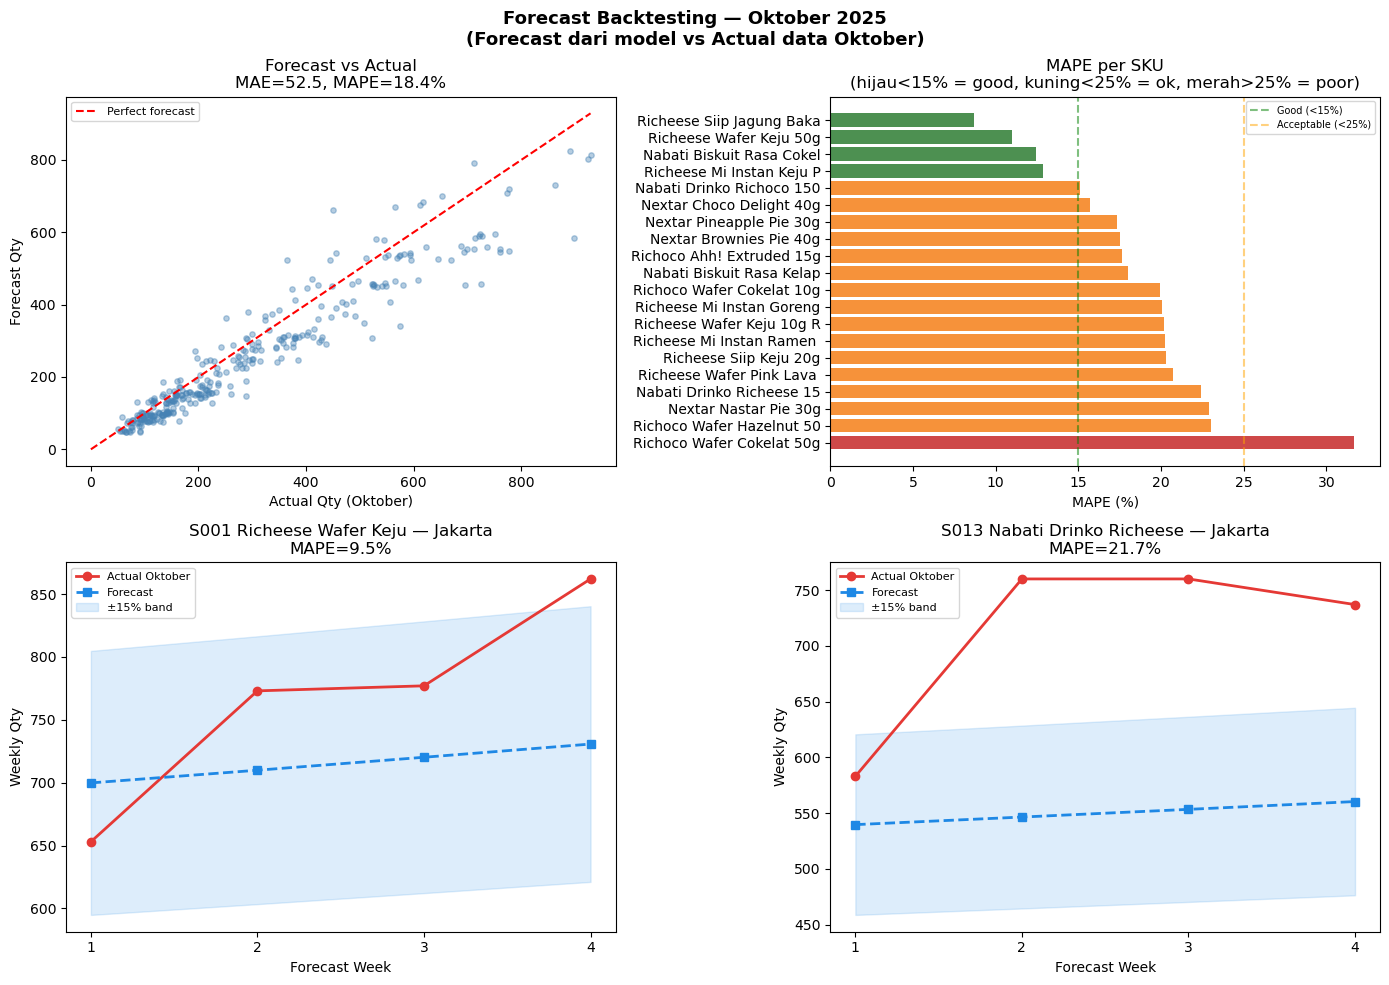


Saved: forecast_backtesting.png

=== Kesimpulan Backtesting ===
Good  (MAPE < 15%) : 4 SKU
OK    (MAPE 15-25%): 15 SKU
Poor  (MAPE > 25%) : 1 SKU

Overall MAPE 18.4% → ACCEPTABLE — forecast usable dengan catatan uncertainty


In [12]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

df1 = pd.read_csv('transaction_1_v4.csv')
df2 = pd.read_csv('transaction_2_v4.csv')
df  = pd.concat([df1, df2], ignore_index=True)
df['Date'] = pd.to_datetime(df['DateTime']).dt.date
df['Date'] = pd.to_datetime(df['Date'])

sku_meta = (df[['SKU_ID','SKU','Brand','SKU_Category']]
              .drop_duplicates().reset_index(drop=True))

# ── Split data ────────────────────────────────────────────────────────────────
# Train : Mei - Sep (yang dipakai modeling)
# Test  : Oktober   (yang di-exclude, sekarang kita pakai untuk validasi)
df_train = df[df['Date'] <  '2025-10-01']
df_test  = df[df['Date'] >= '2025-10-01']

print(f"Train: {df_train['Date'].min().date()} → {df_train['Date'].max().date()} ({len(df_train):,} rows)")
print(f"Test : {df_test['Date'].min().date()} → {df_test['Date'].max().date()} ({len(df_test):,} rows)")

# ── Weekly aggregate train ────────────────────────────────────────────────────
df_train['Week'] = df_train['Date'].dt.to_period('W')
weekly_train = (df_train.groupby(['Week','Branch','SKU_ID'])['Qty']
                        .sum().reset_index(name='WeeklyQty'))
weekly_train['WeekNum'] = weekly_train.groupby(['Branch','SKU_ID'])['Week'].transform(
    lambda x: (x.rank(method='dense')-1).astype(int))

# ── Weekly aggregate test (Oktober) ──────────────────────────────────────────
df_test['Week'] = df_test['Date'].dt.to_period('W')
weekly_test = (df_test.groupby(['Week','Branch','SKU_ID'])['Qty']
                      .sum().reset_index(name='ActualQty'))

# Assign ForecastWeek 1-4 ke minggu Oktober
weekly_test['ForecastWeek'] = weekly_test.groupby(['Branch','SKU_ID'])['Week'].transform(
    lambda x: (x.rank(method='dense')).astype(int))

# Beberapa SKU mungkin punya >4 minggu di Oktober, cap di 4
weekly_test = weekly_test[weekly_test['ForecastWeek'] <= 4]

print(f"\nOktober weeks available per SKU:")
print(weekly_test.groupby('SKU_ID')['ForecastWeek'].max().value_counts())

# ── Re-run forecast dari train data ──────────────────────────────────────────
forecast_results = []

for sku_id in weekly_train['SKU_ID'].unique():
    for branch in weekly_train['Branch'].unique():
        sub = (weekly_train[(weekly_train['SKU_ID']==sku_id) &
                            (weekly_train['Branch']==branch)]
               .sort_values('WeekNum'))

        if len(sub) < 8:
            continue

        X = sub['WeekNum'].values.reshape(-1,1)
        y = sub['WeeklyQty'].values

        model = LinearRegression().fit(X, y)
        y_pred = model.predict(X)

        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - y.mean())**2)
        r2     = 1 - ss_res/ss_tot if ss_tot > 0 else 0

        slope        = model.coef_[0]
        rolling_mean = sub['WeeklyQty'].tail(4).mean()
        last_week    = sub['WeekNum'].max()
        use_linear   = (r2 > 0.3 and abs(slope) < 100)

        for fw in range(1, 5):
            if use_linear:
                base_fc = max(model.predict([[last_week + fw]])[0], 0)
                method  = 'linear_trend'
            else:
                growth_rate = np.clip(
                    slope / rolling_mean if rolling_mean > 0 else 0,
                    -0.05, 0.05)
                base_fc = max(rolling_mean * (1 + growth_rate)**fw, 0)
                method  = 'trend_rolling_mean'

            forecast_results.append({
                'SKU_ID':        sku_id,
                'Branch':        branch,
                'ForecastWeek':  fw,
                'ForecastQty':   round(base_fc, 1),
                'Method':        method,
                'Trend_R2':      round(r2, 4),
            })

forecast_df = pd.DataFrame(forecast_results)

# ── Gabungkan forecast vs actual ─────────────────────────────────────────────
comparison = (weekly_test[['SKU_ID','Branch','ForecastWeek','ActualQty']]
              .merge(forecast_df[['SKU_ID','Branch','ForecastWeek','ForecastQty','Method']],
                     on=['SKU_ID','Branch','ForecastWeek'])
              .merge(sku_meta, on='SKU_ID'))

print(f"\n=== Comparison shape: {comparison.shape} ===")
print(f"Pairs available: {len(comparison)}")

# ── Accuracy metrics ──────────────────────────────────────────────────────────
# MAE  = Mean Absolute Error → rata-rata selisih absolut (dalam unit)
# MAPE = Mean Absolute Percentage Error → rata-rata % error
#        Standard metric untuk forecast accuracy di literatur
#        Referensi: Hyndman & Athanasopoulos (2021) Ch.5

mae  = mean_absolute_error(comparison['ActualQty'], comparison['ForecastQty'])
mape = mean_absolute_percentage_error(comparison['ActualQty'], comparison['ForecastQty']) * 100

print(f"\n=== Overall Forecast Accuracy ===")
print(f"MAE  : {mae:.1f} unit")
print(f"MAPE : {mape:.1f}%")
print(f"Interpretasi: rata-rata forecast meleset {mape:.1f}% dari actual")

# ── Accuracy per SKU ──────────────────────────────────────────────────────────
print("\n=== MAPE per SKU ===")
mape_sku = (comparison.groupby(['SKU_ID','SKU'])
                      .apply(lambda x: mean_absolute_percentage_error(
                          x['ActualQty'], x['ForecastQty']) * 100)
                      .reset_index(name='MAPE')
                      .sort_values('MAPE'))
print(mape_sku[['SKU','MAPE']].to_string(index=False))

# ── Accuracy per forecast week ────────────────────────────────────────────────
print("\n=== MAPE per Forecast Week ===")
mape_week = (comparison.groupby('ForecastWeek')
                       .apply(lambda x: mean_absolute_percentage_error(
                           x['ActualQty'], x['ForecastQty']) * 100)
                       .reset_index(name='MAPE'))
print(mape_week.to_string(index=False))
print("(harusnya Week 1 paling akurat, Week 4 paling meleset)")

# ── Visualisasi ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Forecast Backtesting — Oktober 2025\n(Forecast dari model vs Actual data Oktober)',
             fontsize=13, fontweight='bold')

# Chart 1: Scatter forecast vs actual (semua SKU semua branch)
ax = axes[0,0]
ax.scatter(comparison['ActualQty'], comparison['ForecastQty'],
           alpha=0.4, s=15, color='steelblue')
max_val = max(comparison['ActualQty'].max(), comparison['ForecastQty'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect forecast')
ax.set_xlabel('Actual Qty (Oktober)')
ax.set_ylabel('Forecast Qty')
ax.set_title(f'Forecast vs Actual\nMAE={mae:.1f}, MAPE={mape:.1f}%')
ax.legend(fontsize=8)

# Chart 2: MAPE per SKU
ax = axes[0,1]
colors_bar = ['#2E7D32' if m < 15 else '#F57F17' if m < 25 else '#C62828'
              for m in mape_sku['MAPE']]
ax.barh(mape_sku['SKU'].str[:25], mape_sku['MAPE'],
        color=colors_bar, alpha=0.85)
ax.axvline(15, color='green', linestyle='--', alpha=0.5, label='Good (<15%)')
ax.axvline(25, color='orange', linestyle='--', alpha=0.5, label='Acceptable (<25%)')
ax.set_xlabel('MAPE (%)')
ax.set_title('MAPE per SKU\n(hijau<15% = good, kuning<25% = ok, merah>25% = poor)')
ax.legend(fontsize=7)
ax.invert_yaxis()

# Chart 3: Sample SKU — actual vs forecast per minggu (S001 Jakarta)
ax = axes[1,0]
s001 = comparison[(comparison['SKU_ID']=='S001') &
                  (comparison['Branch']=='Jakarta')].sort_values('ForecastWeek')
if len(s001) > 0:
    ax.plot(s001['ForecastWeek'], s001['ActualQty'],
            marker='o', color='#E53935', linewidth=2, label='Actual Oktober')
    ax.plot(s001['ForecastWeek'], s001['ForecastQty'],
            marker='s', color='#1E88E5', linewidth=2, linestyle='--',
            label='Forecast')
    ax.fill_between(s001['ForecastWeek'],
                    s001['ForecastQty'] * 0.85,
                    s001['ForecastQty'] * 1.15,
                    alpha=0.15, color='#1E88E5', label='±15% band')
    s001_mape = mean_absolute_percentage_error(
        s001['ActualQty'], s001['ForecastQty']) * 100
    ax.set_title(f'S001 Richeese Wafer Keju — Jakarta\nMAPE={s001_mape:.1f}%')
    ax.set_xlabel('Forecast Week')
    ax.set_ylabel('Weekly Qty')
    ax.legend(fontsize=8)
    ax.set_xticks([1,2,3,4])

# Chart 4: Sample SKU — S013 (strong trend) Jakarta
ax = axes[1,1]
s013 = comparison[(comparison['SKU_ID']=='S013') &
                  (comparison['Branch']=='Jakarta')].sort_values('ForecastWeek')
if len(s013) > 0:
    ax.plot(s013['ForecastWeek'], s013['ActualQty'],
            marker='o', color='#E53935', linewidth=2, label='Actual Oktober')
    ax.plot(s013['ForecastWeek'], s013['ForecastQty'],
            marker='s', color='#1E88E5', linewidth=2, linestyle='--',
            label='Forecast')
    ax.fill_between(s013['ForecastWeek'],
                    s013['ForecastQty'] * 0.85,
                    s013['ForecastQty'] * 1.15,
                    alpha=0.15, color='#1E88E5', label='±15% band')
    s013_mape = mean_absolute_percentage_error(
        s013['ActualQty'], s013['ForecastQty']) * 100
    ax.set_title(f'S013 Nabati Drinko Richeese — Jakarta\nMAPE={s013_mape:.1f}%')
    ax.set_xlabel('Forecast Week')
    ax.set_ylabel('Weekly Qty')
    ax.legend(fontsize=8)
    ax.set_xticks([1,2,3,4])

plt.tight_layout()
plt.savefig('forecast_backtesting.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nSaved: forecast_backtesting.png")

# ── Kesimpulan ────────────────────────────────────────────────────────────────
print("\n=== Kesimpulan Backtesting ===")
good    = (mape_sku['MAPE'] < 15).sum()
ok      = ((mape_sku['MAPE'] >= 15) & (mape_sku['MAPE'] < 25)).sum()
poor    = (mape_sku['MAPE'] >= 25).sum()
print(f"Good  (MAPE < 15%) : {good} SKU")
print(f"OK    (MAPE 15-25%): {ok} SKU")
print(f"Poor  (MAPE > 25%) : {poor} SKU")
print(f"\nOverall MAPE {mape:.1f}% → ", end='')
if mape < 15:
    print("GOOD — forecast reliable untuk business use")
elif mape < 25:
    print("ACCEPTABLE — forecast usable dengan catatan uncertainty")
else:
    print("POOR — forecast perlu improvement")